In [1]:
import re
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from gensim.models.fasttext import FastText


Зчитати файл doc12. Вважати кожен рядок окремим документом корпусу. Виконати попередню обробку корпусу.

In [2]:
with open("doc12.txt", "r") as f:
    corpus_raw = [line.strip() for line in f if line.strip()]

In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


corpus = [preprocess(doc) for doc in corpus_raw]

print(f"Corpus: {len(corpus)} documents")
for i, doc in enumerate(corpus):
    print(f"  [{i}] {doc[:100]}...")

Corpus: 7 documents
  [0] a new european directive could put software writers at risk of legal action warns former programmer ...
  [1] he mayor said he had recounted to the assembly a number of examples of intrusion by journalists into...
  [2] on the other hand you probably dont know someone with a milk allergy because thats much less common...
  [3] more directly once software patents are granted then any programmer will have to worry that the code...
  [4] bill thompson is a regular commentator on the bbc world service programme go digital...
  [5] thats because they have a true allergy which means the root of the problem is not in their digestive...
  [6] on tuesday the mayor said he would be making a full written response to the chairman of the assembly...


1)Представити корпус як модель «Сумка n-грам», взяти уні- та біграми. Вивести отриману модель у вигляді таблиці. Вивести вектор для bill thompson.

In [ ]:
cv_bi = CountVectorizer(ngram_range=(2, 2))
cv_bi_matrix = cv_bi.fit_transform(corpus)
df_bigrams = pd.DataFrame(
    cv_bi_matrix.toarray(), index=doc_names, columns=cv_bi.get_feature_names_out()
)

print(
    f"\n--- Bag of Bigrams ({df_bigrams.shape[0]} docs × {df_bigrams.shape[1]} bigrams) ---"
)

print(df_bigrams.to_string())


cv_uni_bi = CountVectorizer(ngram_range=(1, 2))
cv_uni_bi_matrix = cv_uni_bi.fit_transform(corpus)
df_uni_bi = pd.DataFrame(
    cv_uni_bi_matrix.toarray(),
    index=doc_names,
    columns=cv_uni_bi.get_feature_names_out(),
)

print(
    f"\n--- Bag of Uni+Bigrams ({df_uni_bi.shape[0]} docs × {df_uni_bi.shape[1]} features) ---"
)

print(df_uni_bi.to_string())


--- Bag of Bigrams (7 docs × 126 bigrams) ---
       action warns  allergy because  allergy which  analyst bill  and his  and technology  any programmer  are granted  are writing  assembly number  at risk  bbc world  be making  because thats  because they  bill thompson  but rather  by journalists  chairman of  code they  commentator on  could put  digestive systems  directive could  directly once  dont know  elses patent  european directive  examples of  familys private  former programmer  full written  go digital  granted then  had recounted  hand you  have to  have true  he had  he mayor  he would  his and  his familys  immune systems  in their  infringing someone  into his  intrusion by  is infringing  is not  is regular  journalists into  know someone  legal action  less common  making full  mayor said  means the  milk allergy  more directly  much less  new european  not in  number of  of examples  of intrusion  of legal  of the  on the  on tuesday  once software  other hand  pat

In [6]:
query = "bill thompson"
query_vec = cv_uni_bi.transform([query])

df_query = pd.DataFrame(
    query_vec.toarray(), index=[f'"{query}"'], columns=cv_uni_bi.get_feature_names_out()
)
nonzero_cols = df_query.columns[df_query.iloc[0] > 0]

print(f'\n--- Vector for "{query}" (non-zero features) ---')
print(df_query[nonzero_cols].to_string())


--- Vector for "bill thompson" (non-zero features) ---
                 bill  bill thompson  thompson
"bill thompson"     1              1         1


2)Представити корпус як модель TF-IDF. Вивести отриману модель у вигляді таблиці. Використовуючи отриману текстову модель, кластеризувати документи за допомогою ієрархічної агломераційної кластеризації. Вивести результати кластеризації (документ-кластер).

In [7]:
tv = TfidfVectorizer(min_df=0.0, max_df=1.0, norm="l2", use_idf=True, smooth_idf=True)
tv_matrix = tv.fit_transform(corpus)

df_tfidf = pd.DataFrame(
    np.round(tv_matrix.toarray(), 4),
    index=doc_names,
    columns=tv.get_feature_names_out(),
)

print(f"\n--- TF-IDF matrix ({df_tfidf.shape[0]} docs × {df_tfidf.shape[1]} terms) ---")
print(df_tfidf.to_string())


--- TF-IDF matrix (7 docs × 102 terms) ---
       action  allergy  analyst     and     any    are  assembly      at    bbc      be  because    bill     but      by  chairman    code  commentator  common   could  digestive  digital  directive  directly    dont   elses  european  examples  familys  former    full     go  granted     had    hand    have      he     his  immune      in  infringing    into  intrusion      is  journalists    know   legal    less    life  making   mayor   means    milk    more    much     new     not  number      of      on    once   other  patent  patents  private  probably  problem  programme  programmer     put  rather  recounted  regular  response    risk    root    said  service  software  someone  systems  technology    that   thats     the   their    then    they  thompson      to    true  tuesday   warns   which    will    with  world   worry   would  writers  writing  written     you
Doc 0  0.2369   0.0000   0.2369  0.1966  0.0000  0.000    0.0000  

In [8]:
similarity_matrix = cosine_similarity(tv_matrix)
df_sim = pd.DataFrame(
    np.round(similarity_matrix, 4), index=doc_names, columns=doc_names
)

print(df_sim.to_string())

        Doc 0   Doc 1   Doc 2   Doc 3   Doc 4   Doc 5   Doc 6
Doc 0  1.0000  0.0719  0.0000  0.0671  0.1002  0.0172  0.0239
Doc 1  0.0719  1.0000  0.0124  0.0314  0.0145  0.0486  0.2998
Doc 2  0.0000  0.0124  1.0000  0.0494  0.0588  0.1268  0.0824
Doc 3  0.0671  0.0314  0.0494  1.0000  0.0460  0.0919  0.0644
Doc 4  0.1002  0.0145  0.0588  0.0460  1.0000  0.0562  0.0963
Doc 5  0.0172  0.0486  0.1268  0.0919  0.0562  1.0000  0.0882
Doc 6  0.0239  0.2998  0.0824  0.0644  0.0963  0.0882  1.0000


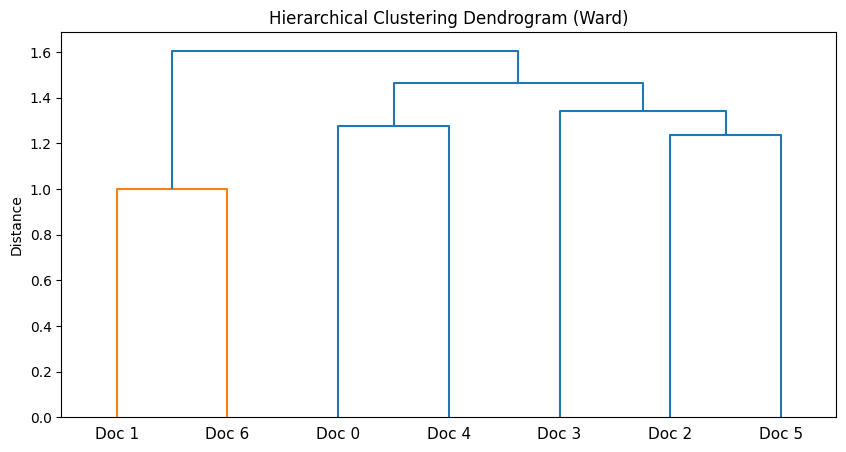

In [12]:
links = linkage(similarity_matrix, method="ward")

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(links, labels=doc_names, leaf_font_size=11, ax=ax)
ax.set_title("Hierarchical Clustering Dendrogram (Ward)")
ax.set_ylabel("Distance")
plt.show()

In [ ]:
def print_clusters(labels, title):
    print(f"\n--- {title} ---")
    for i, cl in enumerate(labels):
        print(f"  Doc {i} -> Cluster {cl}")


max_dist = 1.5
cluster_labels = fcluster(links, max_dist, criterion="distance")
print_clusters(cluster_labels, f"Clusters (fcluster, max_dist={max_dist})")

ag = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
ag.fit(tv_matrix.toarray())
print_clusters(ag.labels_, "AgglomerativeClustering (n_clusters=3)")

print("\nCluster summary:")
for cl in sorted(set(ag.labels_)):
    docs = [f"Doc {i}" for i, l in enumerate(ag.labels_) if l == cl]
    print(f'  Cluster {cl}: {", ".join(docs)}')

In [ ]:
3)Представити корпус як модель FastText. Вивести вектори слів mixer, medical. Знайти подібні слова до слів mixer, medical.

In [15]:
tokenizer = nltk.WordPunctTokenizer()
tokenized_corpus = [tokenizer.tokenize(doc) for doc in corpus]

print("\n--- Tokenized corpus ---")
for i, tokens in enumerate(tokenized_corpus):
    preview = tokens[:10]
    print(f'  Doc {i}: {preview}{"..." if len(tokens) > 10 else ""}')

ft_model = FastText(
    tokenized_corpus, vector_size=100, window=50, min_count=1, sample=1e-3, sg=1
)
print(f"\nFastText model trained — vocabulary size: {len(ft_model.wv)}")


--- Tokenized corpus ---
  Doc 0: ['a', 'new', 'european', 'directive', 'could', 'put', 'software', 'writers', 'at', 'risk']...
  Doc 1: ['he', 'mayor', 'said', 'he', 'had', 'recounted', 'to', 'the', 'assembly', 'a']...
  Doc 2: ['on', 'the', 'other', 'hand', 'you', 'probably', 'dont', 'know', 'someone', 'with']...
  Doc 3: ['more', 'directly', 'once', 'software', 'patents', 'are', 'granted', 'then', 'any', 'programmer']...
  Doc 4: ['bill', 'thompson', 'is', 'a', 'regular', 'commentator', 'on', 'the', 'bbc', 'world']...
  Doc 5: ['thats', 'because', 'they', 'have', 'a', 'true', 'allergy', 'which', 'means', 'the']...
  Doc 6: ['on', 'tuesday', 'the', 'mayor', 'said', 'he', 'would', 'be', 'making', 'a']...

FastText model trained — vocabulary size: 103


In [16]:
for word in ["mixer", "medical"]:
    vec = ft_model.wv[word]
    print(f'\nVector for "{word}" (first 10 dims): {np.round(vec[:10], 4).tolist()}')
    similar = ft_model.wv.most_similar(word, topn=10)
    print(f'Words most similar to "{word}":')
    for w, score in similar:
        print(f"  {w:20s}  {score:.4f}")


Vector for "mixer" (first 10 dims): [0.00039999998989515007, -0.0008999999845400453, 0.0003000000142492354, 9.999999747378752e-05, 0.0005000000237487257, 0.0003000000142492354, 0.002099999925121665, -0.0019000000320374966, 0.0017999999690800905, 0.0012000000569969416]
Words most similar to "mixer":
  means                 0.1969
  writing               0.1770
  former                0.1695
  writers               0.1676
  patents               0.1597
  dont                  0.1558
  with                  0.1371
  in                    0.1197
  other                 0.1175
  rather                0.1091

Vector for "medical" (first 10 dims): [0.0010999999940395355, -0.0003000000142492354, -0.0010000000474974513, -0.0005000000237487257, 0.003100000089034438, -0.0015999999595806003, 0.0013000000035390258, 0.0012000000569969416, -0.0, 0.0008999999845400453]
Words most similar to "medical":
  other                 0.3514
  examples              0.3017
  common                0.2201
  go   